# Extract Films from filmaffinity

In [16]:
#!pip install streamlit
#!pip install selenium

In [17]:
import time
import pandas as pd
import numpy as np
from selenium import webdriver
from selenium.webdriver.common.by import By
import requests
from bs4 import BeautifulSoup

```html
                <li class="position">1</li>
                <li class="content">
<div class="movie-card mc-flex movie-card-0" data-movie-id="809297">
    <div class="mc-poster">
        <a href="https://www.filmaffinity.com/es/film809297.html"><img width="100" height="" src="https://pics.filmaffinity.com/the_godfather-488102675-msmall.jpg" data-src="https://pics.filmaffinity.com/the_godfather-488102675-msmall.jpg" alt="El padrino " class=" ls-is-cached lazyloaded"></a>
    </div>
    <div class="mc-info-container">
        <div class="mc-title"><a href="https://www.filmaffinity.com/es/film809297.html" title="El padrino">El padrino</a></div>
        <div class="d-flex">
            <img class="nflag" src="/imgs/countries2/US.png" alt="Estados Unidos"><span class="mc-year">1972</span>
        </div>        
        <div class="mc-director"><div class="credits"><span class="nb"><a href="https://www.filmaffinity.com/es/name.php?name-id=845159519" title="Francis Ford Coppola">Francis Ford Coppola</a></span></div></div>
        <div class="mc-cast"><div class="credits"><span class="nb"><a href="https://www.filmaffinity.com/es/name.php?name-id=847880194" title="Marlon Brando">Marlon Brando</a>,</span> <span class="nb"><a href="https://www.filmaffinity.com/es/name.php?name-id=951364861" title="Al Pacino">Al Pacino</a>,</span> <span class="nb"><a href="https://www.filmaffinity.com/es/name.php?name-id=528190012" title="James Caan">James Caan</a>,</span> <span class="nb"><a href="https://www.filmaffinity.com/es/name.php?name-id=514295914" title="Robert Duvall">Robert Duvall</a>,</span> <span class="nb"><a href="https://www.filmaffinity.com/es/name.php?name-id=568095076" title="Diane Keaton">Diane Keaton</a></span> ...</div></div>
    </div>

    <div class="mc-actions">
            <div class="mc-action"><a class="addl" title="Añadir a listas" href="https://www.filmaffinity.com/es/edtmovielists.php?movie_id=809297&amp;rp=%2Fes%2Ftopgen.php"><i class="fas fa-list"></i></a></div>
    </div>

    <div class="lists-box"></div>
</div>



                </li>
                <li class="data">
                    <div class="avg-rating">9,0</div>
                    <div class="rat-count">178.328 <i class="fa fa-simple-user-o-fa"></i></div>
                    <div class="avgrat-box-ur">8</div>
                    <div class="rate-date"><small>21/01/2025</small></div>


                </li>

In [ ]:
options = webdriver.FirefoxOptions()
driver = webdriver.Firefox(options=options)

url = 'https://www.filmaffinity.com/es/topgen.php?genres=&chv=0&orderby=avg&movietype=movie%7C&country=&fromyear=1874&toyear=2026&ratingcount=0&runtimemin=0&runtimemax=4'

driver.get(url)
time.sleep(2)
ACCEPT_CSS_SELECTOR = '#accept-btn'
driver.find_element(By.CSS_SELECTOR, ACCEPT_CSS_SELECTOR).click()

top_films = []

for film_position in range(1, 100):
    li_num = film_position
    ul_num = 1
    FILM_CARD_CSS_SELECTOR = f'#top-movies > li:nth-child({li_num}) > ul:nth-child({ul_num})'''
    try:
        film_card = driver.find_element(By.CSS_SELECTOR, FILM_CARD_CSS_SELECTOR)
        top_films.append(film_card)
    except:
        pass

len(top_films)

30

In [19]:
top_films[29].text.split('\n')

['30',
 'Alguien voló sobre el nido del cuco',
 '1975',
 'Milos Forman',
 'Jack Nicholson, Louise Fletcher, Brad Dourif, William Redfield, Mews Small ...',
 '8,3',
 '113.987']

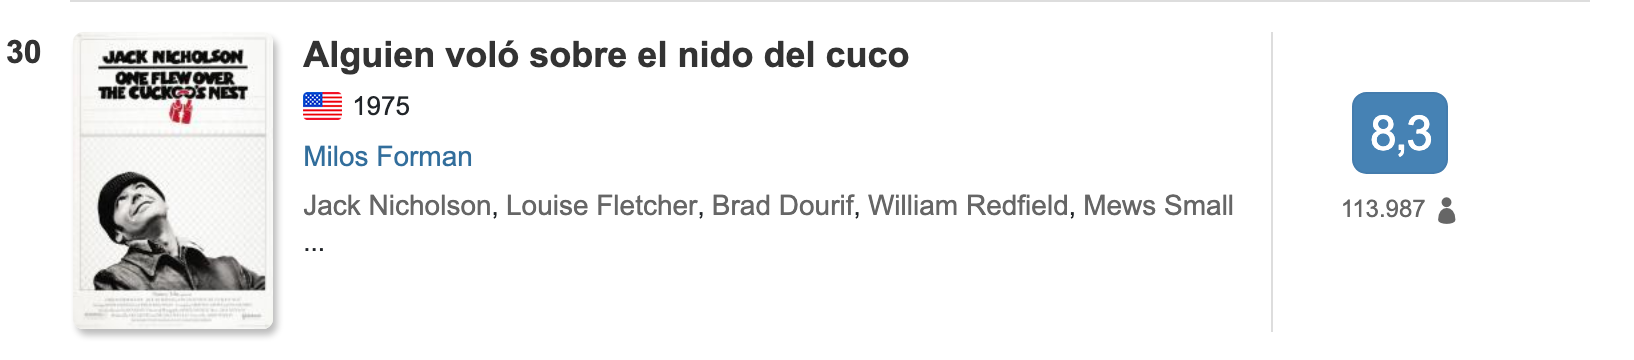

In [26]:
film_image = top_films[29].screenshot_as_png

from PIL import Image
import io
from IPython.display import display

image = Image.open(io.BytesIO(film_image))
display(image)